# Shield Synthesis on a Custom MASA Environment (Bridge Crossing)

This tutorial applies `projects.safe_crl.utils.shield_utils` to a **custom MASA-style
tabular environment**, `CustomBridgeCrossing-v0`, using exactly the algorithm the real
`projects/safe_crl/pipelines/safety_retention/synthesise_shield.py` /
`projects/safe_policy_optimisation/stages/synthesise_shield.py` pipelines run for every
`Custom*-v0` environment in this repo.

`CustomBridgeCrossing-v0` places the agent south of a strip of lava with a narrow gap (the
"bridge") in it, and a goal region north of the lava. Each move can slip sideways with
probability `slip_prob`, so crossing the bridge carries some risk of falling into the lava.

The notebook:

1. builds a small `CustomBridgeCrossing-v0` instance,
2. synthesises a **probabilistic safety shield** via exact tabular value iteration,
3. visualises the shield over the rendered grid, and
4. states precisely what safety guarantee the shield provides.

**Note on the shield's semantics:** the shield allows only the action(s) that achieve the
*minimum* eventual-unsafe-reachability risk in each state — the safest policy the
environment admits. There is no externally chosen risk threshold ("alpha") to tune; the
guaranteed safety rate is simply whatever the computed risk turns out to be.

## Imports

As in the FrozenLake shield tutorial, we call `synthesise_probabilistic_shield` with
`use_masa_helper=False` so the notebook runs without the `MASA-Safe-RL` package installed;
production runs leave `use_masa_helper=True` (the default) and fall back to the local
implementation only when MASA isn't installed.

**Scope note:** this is exact tabular value iteration — it needs a fully enumerated
transition matrix `P(s'|s,a)` up front, so it only applies to environments with a small,
finite, enumerable state space (like the `Custom*` tabular envs here), not to continuous or
image-observation environments.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path("/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import projects.safe_crl.utils.masa_tabular_envs  # registers Custom* env IDs
from projects.safe_crl.utils.masa_tabular_envs.factory import make_custom_masa_env
from projects.safe_crl.utils.masa_tabular_envs.visualisation import (
    plot_tabular_shield,
    print_allowed_actions,
)
from projects.safe_crl.utils.shield_utils import (
    synthesise_deterministic_shield,
    synthesise_probabilistic_shield,
)

I0000 00:00:1782999572.282710  952542 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782999572.374685  952542 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782999576.190781  952542 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## A Small Bridge-Crossing Task

`CustomBridgeCrossing-v0` defaults to a 20x20 grid; we shrink it to 8x8 here purely so the
value-iteration residual converges quickly and the shield plot stays readable. The layout
keeps the same shape as the real task: a goal row, a lava row with a 2-cell gap (the
bridge), and a start cell on the far side of the lava.

- `goal_states`: the whole top row - reaching any of these ends the episode safely.
- `lava_states`: the middle row, except columns 3-4 (the bridge) - entering any of these
  ends the episode unsafely.
- `start_state`: the bottom-left corner, as far from the bridge as possible.

We build two instances: a deterministic one (`slip_prob=0.0`, actions never slip) and a
stochastic one (`slip_prob=0.1`, each action has a 10% chance of moving in a random other
direction instead) - matching the `stochasticity: {slip_prob: ...}` knob used by the real
`CustomBridgeCrossing/settings/tasks/tasks.yaml` task library.

/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


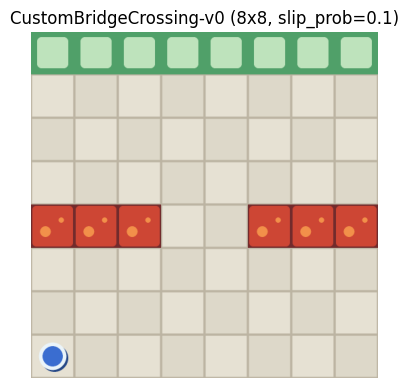

In [2]:
GRID_SIZE = 8
GRID = np.arange(GRID_SIZE**2).reshape(GRID_SIZE, GRID_SIZE)
GOAL_STATES = [int(s) for s in GRID[0, :]]
LAVA_STATES = [int(s) for s in GRID[4, :3]] + [int(s) for s in GRID[4, 5:]]
START_STATE = int(GRID[7, 0])

BASE_KWARGS = dict(
    grid_size=GRID_SIZE,
    goal_states=GOAL_STATES,
    lava_states=LAVA_STATES,
    start_state=START_STATE,
)


def make_bridge_env(slip_prob: float):
    env = make_custom_masa_env(
        "CustomBridgeCrossing-v0",
        env_kwargs={**BASE_KWARGS, "slip_prob": slip_prob},
        render_mode="rgb_array",
    )
    env.reset(seed=0)
    return env


deterministic_env = make_bridge_env(slip_prob=0.0)
stochastic_env = make_bridge_env(slip_prob=0.1)

frame = stochastic_env.render()
plt.figure(figsize=(4.5, 4.5))
plt.imshow(frame)
plt.axis("off")
plt.title("CustomBridgeCrossing-v0 (8x8, slip_prob=0.1)")
plt.show()

## Shield Inputs: Labels and Cost

Every `Custom*` tabular env exposes `label_fn(state) -> set[str]` and
`cost_fn(labels) -> float`. For `CustomBridgeCrossing-v0`, `cost_fn` returns `1.0` exactly
when `"lava"` is one of the state's labels, and `0.0` otherwise - that is what makes lava
cells "unsafe" for shield synthesis.

In [3]:
unwrapped = stochastic_env.unwrapped


def transition_matrix_fn(env) -> np.ndarray:
    return env.get_transition_matrix()


for state in [START_STATE, LAVA_STATES[0], GOAL_STATES[0]]:
    labels = unwrapped.label_fn(state)
    print(f"state {state:3d}: labels={sorted(labels)}, cost={unwrapped.cost_fn(labels)}")

state  56: labels=['start'], cost=0.0
state  32: labels=['lava'], cost=1.0
state   0: labels=['goal'], cost=0.0


## Synthesise the Shield

`synthesise_probabilistic_shield` runs exact tabular value iteration over the transition
matrix to compute, for every `(state, action)`, `action_risk[s, a]` - the minimal
probability of *eventually* entering lava if you take `a` in `s` and then play optimally
for safety thereafter. It then builds the shield by keeping only the safest action(s) per
state (within `theta`).

This mirrors exactly what `run_masa_env` in
`projects/safe_crl/pipelines/safety_retention/synthesise_shield.py` does for every
`Custom*-v0` environment in the real pipelines - the only difference here is
`use_masa_helper=False` so the notebook runs standalone.

We use a larger `max_vi_steps` than the library default because this small grid's slip
probability makes the interval value iteration converge slowly; `vi_residual` reports how
tight the returned risk values actually are.

In [4]:
shield, info = synthesise_probabilistic_shield(
    stochastic_env,
    transition_matrix_fn,
    unwrapped.label_fn,
    unwrapped.cost_fn,
    theta=1e-10,
    max_vi_steps=25_000,
    use_masa_helper=False,
    return_info=True,
)

state_safety = 1.0 - info.state_risk

print("Shield shape:", shield.shape)
print("Value-iteration steps used:", info.vi_steps)
print("Value-iteration residual:", info.vi_residual)
print(f"Guaranteed safety probability from the start state: {state_safety[START_STATE]:.4f}")
print("Mean number of allowed (safest) actions per state:", shield.sum(axis=1).mean())

Shield shape: (64, 5)
Value-iteration steps used: 18485
Value-iteration residual: 8.194983580622761e-11
Guaranteed safety probability from the start state: 0.9707
Mean number of allowed (safest) actions per state: 1.40625


## Visualise the Shield

`plot_tabular_shield` (from `masa_tabular_envs.visualisation`, the same helper the real
`plot_shield.py` uses for MASA envs) renders the environment's frame and draws one arrow
per *shield-allowed* action, coloured green-to-red by its risk. Cells with no arrows are
lava - the shield masks every action there, since the episode already ends unsafely on
entry.

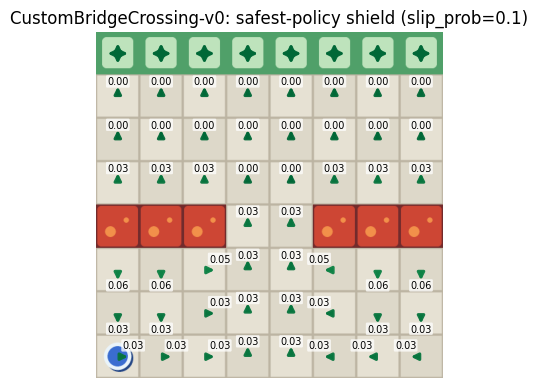

state    0 at row=0, col=0 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    1 at row=0, col=1 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    2 at row=0, col=2 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    3 at row=0, col=3 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    4 at row=0, col=4 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    5 at row=0, col=5 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    6 at row=0, col=6 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    7 at row=0, col=7 labels=['goal']: ['left', 'right', 'down', 'up', 'stay']
state    8 at row=1, col=0 labels=[]: ['up']
state    9 at row=1, col=1 labels=[]: ['up']
state   10 at row=1, col=2 labels=[]: ['up']
state   11 at row=1, col=3 labels=[]: ['up']
state   12 at row=1, col=4 labels=[]: ['up']
state   13 at row=1, col=5 labels=[]: ['up']
state   14 at row=1, col=6 labels=[]: ['up']
state   15 at

In [5]:
ax = plot_tabular_shield(
    stochastic_env,
    shield,
    info=info,
    show_risk=True,
    title="CustomBridgeCrossing-v0: safest-policy shield (slip_prob=0.1)",
)
plt.show()

print_allowed_actions(stochastic_env, shield)

## The Safety Guarantee

For every state `s`, value iteration computes:

```
state_risk[s] = min over all policies of P(the agent eventually enters lava | start in s, follow that policy)
state_safety[s] = 1 - state_risk[s]
```

`state_risk[s]` is therefore the **best possible safety rate any policy can achieve** from
`s` - shielded or not; no policy can do strictly better. The shield allows exactly the
action(s) `a` with `action_risk[s, a] <= state_risk[s] + theta`, i.e. the action(s) that
attain that minimum (up to the value-iteration tolerance `theta`).

**Guarantee:** if an agent always selects a shield-allowed action, from whatever state it is
currently in, then the probability that it ever enters lava is at most
`state_risk[s] + theta` for its current state `s` - and this is the safest rate achievable
by *any* policy, not a threshold chosen by a user. This is exactly why the shield-synthesis
API no longer takes a `risk_threshold`/`alpha` argument: there is nothing to tune, since the
shield always plays the environment's safest admissible policy.

The guarantee is certified only up to the printed `vi_residual` (the gap between the
value-iteration lower and upper bounds when it stopped); shrinking `theta` and increasing
`max_vi_steps` tightens it further, at the cost of more computation.

In [6]:
print(f"vi_residual = {info.vi_residual:.2e}  (guarantee is exact up to this tolerance)")
print()
print("state_safety over the grid (row 0 = goal, row 4 = lava with a bridge at cols 3-4):")
print(np.round(state_safety.reshape(GRID_SIZE, GRID_SIZE), 4))

vi_residual = 8.19e-11  (guarantee is exact up to this tolerance)

state_safety over the grid (row 0 = goal, row 4 = lava with a bridge at cols 3-4):
[[1.     1.     1.     1.     1.     1.     1.     1.    ]
 [1.     1.     1.     1.     1.     1.     1.     1.    ]
 [0.9992 0.9992 0.9993 0.9999 0.9999 0.9993 0.9992 0.9992]
 [0.9722 0.9722 0.9729 0.9985 0.9985 0.9729 0.9722 0.9722]
 [0.     0.     0.     0.9715 0.9715 0.     0.     0.    ]
 [0.9437 0.9438 0.9452 0.9708 0.9708 0.9452 0.9438 0.9437]
 [0.97   0.97   0.9701 0.9707 0.9707 0.9701 0.97   0.97  ]
 [0.9707 0.9707 0.9707 0.9707 0.9707 0.9707 0.9707 0.9707]]


## Bonus: The Deterministic (Almost-Sure) Shield

For comparison, `synthesise_deterministic_shield` computes the *almost-sure* shield on the
`slip_prob=0.0` variant of the same layout: since dynamics are deterministic there, an
action is allowed only if it keeps the agent inside the "winning set" (states from which
lava can be avoided forever with certainty). Where the almost-sure shield allows an action
at all, its guarantee is exact - probability **1**, not `1 - theta`.

Deterministic shield shape: (64, 5)
Winning (almost-surely-safe) states: 58 / 64
Start state is in the winning set: True


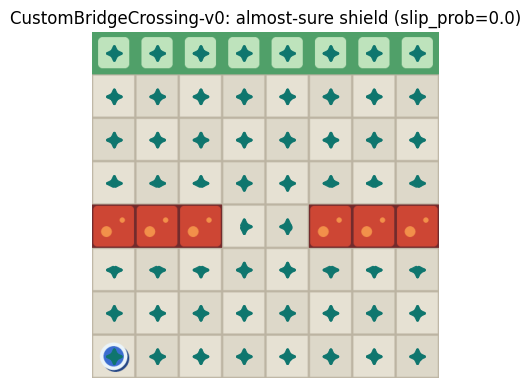

In [7]:
det_unwrapped = deterministic_env.unwrapped

det_shield, det_info = synthesise_deterministic_shield(
    deterministic_env,
    transition_matrix_fn,
    det_unwrapped.label_fn,
    det_unwrapped.cost_fn,
    use_masa_helper=False,
    return_info=True,
)

print("Deterministic shield shape:", det_shield.shape)
print("Winning (almost-surely-safe) states:", len(det_info.winning_states), "/", GRID_SIZE**2)
print("Start state is in the winning set:", START_STATE in set(det_info.winning_states.tolist()))

plot_tabular_shield(
    deterministic_env,
    det_shield,
    title="CustomBridgeCrossing-v0: almost-sure shield (slip_prob=0.0)",
)
plt.show()

## Cleanup

In [8]:
deterministic_env.close()
stochastic_env.close()